In [ ]:
import re
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
from adjustText import adjust_text
from collections import defaultdict
from Bio import SeqIO

In [ ]:
# plot appearance default parameters
mpl.rc('lines', linewidth=0.4)
mpl.rc('font', family="Helvetica", size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=8)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=8)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400

## 1 - Creating AnnData

To store the enhancer data, we create an anndata object, where obs are species, var are enhancers and matrices contain information about each enhancer in every genome (e.g. preservation level or similarity level).

### 1.1 - Initial anndata

In [56]:
# functions and defaults
similarity_scoring = {
    "mismatch_similar_base": -1,     # transition (pur<->pur or pyr<->pyr)
    "mismatch_unsimilar_base": -2,   # transversion (pur<->pyr)
    "gap": -3
}
purines = set("AG")
pyrimidines = set("CT")

def preservation_similarity_calculate(fasta_file, ref_sp, species_order, similarity_scoring=similarity_scoring):
    """
    Returns:
      preservation: fraction of positions (in ref) that match (excluding ref gaps)
      similarity: average similarity score per ref-alignment position (excluding ref gaps)
      out_species: species in the same order as species_order (excluding ref_sp)
    Missing species -> np.nan entries.
    """
    ref_seq = None
    seq_by_sp = {}

    for record in SeqIO.parse(fasta_file, "fasta"):
        sp = record.id
        if sp == ref_sp:
            ref_seq = str(record.seq).upper()
            ref_len = len(ref_seq)
        else:
            seq_by_sp[sp] = str(record.seq).upper()

    if ref_seq is None:
        raise ValueError(f"Reference species '{ref_sp}' not found in {fasta_file}")

    out_species = [sp for sp in species_order if sp != ref_sp]
    preservation = []
    similarity = []

    for sp in out_species:
        seq = seq_by_sp.get(sp)
        if seq is None:
            preservation.append(np.nan)
            similarity.append(np.nan)
            continue

        if len(seq) != len(ref_seq):
            raise ValueError(f"Alignment length mismatch for {sp} in {fasta_file}: {len(seq)} vs {len(ref_seq)}")
        
        p = 0
        s = 0

        for r, c in zip(ref_seq, seq):
            
            if c == "-":
                s += similarity_scoring["gap"]
                continue
            
            p += 1
            
            if c == r:
                continue

            # mismatch: transition vs transversion
            if (r in purines and c in purines) or (r in pyrimidines and c in pyrimidines):
                s += similarity_scoring["mismatch_similar_base"]
            else:
                s += similarity_scoring["mismatch_unsimilar_base"]

        
        preservation.append(p / ref_len)
        similarity.append(s / ref_len)

    return preservation, similarity, out_species

In [57]:
#inputs
fasta_dir = "../output/1_2_FASTA_per_enh"
fasta_files = sorted(glob.glob(os.path.join(fasta_dir, "*.fa")))

with open("../data/0_target_species.txt", "r") as f:
    species_list_sorted = sorted([line.strip() for line in f if line.strip()])
    
ref_sp = "hg38"

In [58]:
#building vectors
enh_names = []
pre_cols = []   # list of vectors of preservation per enhancer in respect to ref
sim_cols = []   # list of vectors of similarity per enhancer in respect to ref


species_no_ref = None

for fp in fasta_files:
    enh_name = os.path.splitext(os.path.basename(fp))[0]
    p, s, out_species = preservation_similarity_calculate(fp, ref_sp, species_list_sorted)

    if species_no_ref is None:
        species_no_ref = out_species
    else:
        # sanity check: ordering consistent
        if out_species != species_no_ref:
            raise ValueError("Species order mismatch between files (unexpected).")

    enh_names.append(enh_name)
    pre_cols.append(p)
    sim_cols.append(s)


# matrices    
preservation_matrix = np.array(pre_cols, dtype=float).T
similarity_matrix = np.array(sim_cols, dtype=float).T

In [72]:
#creating AnnData object
obs = pd.DataFrame(index=species_no_ref) #species
var = pd.DataFrame(index=enh_names) #enhancers

adata = ad.AnnData(X=preservation_matrix, obs=obs, var=var)
adata.layers["similarity"] = similarity_matrix
adata.uns["ref_species"] = ref_sp

### 1.2 - Adding obs and vars

In [73]:
#taxonomy categories for adata.obs
taxonomy_order = {'Primates': ['Macaca_mulatta','Nasalis_larvatus',
                        'Pan_paniscus','Gorilla_gorilla',
                        'Pongo_abelii','Callithrix_jacchus',
                        'Ateles_geoffroyi','Eulemur_flavifrons'],
    'Carnivora': ['Felis_nigripes','Mungos_mungo',
                    'Neomonachus_schauinslandi', 'Ursus_maritimus'],
    'Cetartiodactyla': ['Bison_bison', 'Camelus_ferus',
                    'Balaenoptera_acutorostrata', 'Sus_scrofa'],
    'Perissodactyla': ['Equus_przewalskii', 'Tapirus_indicus',
                        'Ceratotherium_simum'],
    'Rodentia': ['Cavia_aperea', 'Rattus_norvegicus',
                'Mesocricetus_auratus', 'Marmota_marmota']
}


#mapping
species_to_order = {
    sp: order
    for order, spp in taxonomy_order.items()
    for sp in spp
}

adata.obs["order"] = adata.obs_names.map(species_to_order)
adata.obs["order"] = pd.Categorical(adata.obs["order"], categories=list(taxonomy_order.keys()))

In [ ]:
### assigning coordinates and genes to enhancer

#dataframes
enh_info = pd.read_csv('../data/0_SupplementaryTable_Links_11062025(2).csv', sep=',', header=0)
enh_coords = pd.read_csv('../data/0_enhancer_gene_pairs.csv', sep=';', header=0, dtype=str, index_col='genes')

In [ ]:
# adding coordinates
enh_coords.set_index('genes', inplace=True)
enh_coords['coord'] = enh_coords.iloc[:,0] + '-' + enh_coords.iloc[:,1] + '-' + enh_coords.iloc[:,2]

adata.var = pd.merge(adata.var, enh_coords, left_index=True, right_index=True, how='left')
adata.var['enh_length'] = adata.var['stop'].astype(int) - adata.var['start'].astype(int)

In [78]:
adata.var

,chr,start,stop,coord,enh_length
A2M_en1,chr12,6552777,6553565,chr12-6552777-6553565,788
A2M_en2,chr12,6961626,6962570,chr12-6961626-6962570,944
AATK_EIF4A3_en1,chr17,81025157,81026152,chr17-81025157-81026152,995
AATK_en1,chr17,80716905,80719152,chr17-80716905-80719152,2247
AATK_en2,chr17,81314837,81315640,chr17-81314837-81315640,803
...,...,...,...,...,...
ZZZ3_IFI44L_en1,chr1,76637075,76638127,chr1-76637075-76638127,1052
ZZZ3_IFI44L_en2,chr1,79657699,79658654,chr1-79657699-79658654,955
ZZZ3_en1,chr1,76278824,76279903,chr1-76278824-76279903,1079
ZZZ3_en2,chr1,77514127,77515117,chr1-77514127-77515117,990


In [ ]:
# adding all related info from Rozalina's dataframe
subset = enh_info.loc[:, ["key","gene", "name", "Trait","Variation","Position","Vista_region","DAR_coarse","DAR_granular", "DAR_regional"]]

adata.var = adata.var.reset_index().merge(subset, left_on="coord",  right_on="key", how="left").set_index('index')
adata.var.drop(columns=['key'], inplace=True)

In [80]:
adata.var

,chr,start,stop,coord,enh_length,gene,name,Trait,Variation,Position,Vista_region,DAR_coarse,DAR_granular,DAR_regional
index,,,,,,,,,,,,,,
A2M_en1,chr12,6552777,6553565,chr12-6552777-6553565,788,A2M,12_TxEnhW,NaN,NaN,NaN,NaN,"Myoblast,Perivascular,Endothelia","myoblast,pericyte,endothelia",NaN
A2M_en2,chr12,6961626,6962570,chr12-6961626-6962570,944,A2M,13_EnhA1,NaN,NaN,NaN,NaN,"Chondrogenic,Perivascular,Blood,Epithelia","nasal chondrocyte,pericyte,erythrocytes,epithelia",NaN
AATK_EIF4A3_en1,chr17,81025157,81026152,chr17-81025157-81026152,995,"AATK,EIF4A3","19_DNase,15_EnhAF,17_EnhW2",NaN,NaN,NaN,NaN,"Mesenchyme A,Glia,Mesenchyme D (near-dermal),M...","anterior dermal fibroblast,glia,PAX9/PAX7+ nas...",nose
AATK_en1,chr17,80716905,80719152,chr17-80716905-80719152,2247,AATK,"25_Quies,17_EnhW2,8_TxWk",NaN,NaN,NaN,NaN,Glia,glia,NaN
AATK_en2,chr17,81314837,81315640,chr17-81314837-81315640,803,AATK,"15_EnhAF,17_EnhW2",NaN,NaN,NaN,NaN,Glia,glia,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZZZ3_IFI44L_en1,chr1,76637075,76638127,chr1-76637075-76638127,1052,"ZZZ3,IFI44L","25_Quies,18_EnhAc",NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZZZ3_IFI44L_en2,chr1,79657699,79658654,chr1-79657699-79658654,955,"ZZZ3,IFI44L","14_EnhA2,15_EnhAF,25_Quies",NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZZZ3_en1,chr1,76278824,76279903,chr1-76278824-76279903,1079,ZZZ3,"14_EnhA2,8_TxWk",NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.3 Enhancer categories

Categories of enhancers based on preservation score
Groups in hierarcical order:
1) Conservative - more than 18 species have 90% similarity (not only primates) 
2) Primate specific - all primates have >90% of similarity, at least half of others have <10%
3) Human unique - sequence is present in less than 10% of other species
5) Other - the rest cases

In [ ]:
# masks
prim_mask = (adata.obs["order"].astype(str) == "Primates").to_numpy()

nonprim_mask = ~prim_mask

X = adata.X
valid = ~np.isnan(X)

# 1) Conservative: >18 species >= 0.9 (ignoring NaN)
N90 = np.sum((X >= 0.9) & valid, axis=0)          # per enhancer
conservative = N90 > 18

#  2) Primate specific:
# (a) primates >= 0.9 with slack: allow up to 1 primate < 0.9 (ignoring NaN)
X_prim = X[prim_mask, :]
valid_prim = valid[prim_mask, :]

n_prim_valid = np.sum(valid_prim, axis=0)
n_prim_bad = np.sum((X_prim < 0.9) & valid_prim, axis=0)

prim_ok = (n_prim_valid > 0) & (n_prim_bad <= 1)

# (b) all non-primates have <= 0.1 (among valid)
X_nonprim = X[nonprim_mask, :]
valid_nonprim = valid[nonprim_mask, :]

n_nonprim_valid = np.sum(valid_nonprim, axis=0)  # per enhancer
n_nonprim_low10 = np.sum((X_nonprim <= 0.1) & valid_nonprim, axis=0)

all_nonprim_low10 = (n_nonprim_valid > 0) & (n_nonprim_low10 >= 0.5 * n_nonprim_valid)

primate_specific = prim_ok & all_nonprim_low10

# 3) Human unique:
all_low10 = np.all((X < 0.1) | ~valid, axis=0) #appears only in humans

In [82]:
# basic array (shape = 1 x adata.X[1])
enh_cat = np.array(['other'] * adata.n_vars, dtype=object)

#Conservative (CON)
enh_cat[conservative] = 'conservative'

#Primate specific (PS)
mask_pc = (enh_cat == 'other') & primate_specific
enh_cat[mask_pc] = 'primate_specific'

#Human unique (HU)
enh_cat[all_low10] = 'human_unique'

#Adding to adata
adata.var['category'] = pd.Categorical(
    enh_cat,
    categories=["conservative","primate_specific", "human_unique", "other"],
    ordered=True
)

In [83]:
adata.var['category'].value_counts()

category
other               8730
conservative        2929
primate_specific      84
human_unique           5
Name: count, dtype: int64

### 1.4 Integrating SNPs info

In [84]:
snp_pos = pd.read_csv('../data/0_hg38_SNPs.bed', sep='\t', header=None, names=['pos_chr', 'pos_hg38', 'no_need', 'pos_hg19'], index_col=0)
snp_pos.drop(columns=['no_need'], inplace=True)
snp_pos['pos_hg19'] = snp_pos['pos_hg19'].str.split(':', expand=True)[1]
snp_pos[['pos_hg38','pos_hg19']] = snp_pos[['pos_hg38','pos_hg19']].astype(int)
snp_pos

,pos_hg38,pos_hg19
pos_chr,,
chr1,1043223,978603
chr1,1755713,1687152
chr1,2270305,2201744
chr1,2844810,2761375
chr1,2882147,2798712
...,...,...
chr22,45447383,45843264
chr22,45780034,46175914
chr22,45987732,46383612


In [85]:
def falls_into_reg(row, df_pos):
    chrom = row['chr']
    start = row['start']
    stop = row['stop']
    
    if chrom not in df_pos.index:
        return None
    
    sub_df = df_pos.loc[chrom]
    positions = sub_df.iloc[:,0].values
    
    matches = []
    for pos in positions:
        if start <= pos <= stop:
            matches.append(str(pos))
    
    return ','.join(matches) if matches else np.nan

In [86]:
adata.var[['start', 'stop']] = adata.var[['start', 'stop']].astype(int)

adata.var['snps'] = adata.var.apply(falls_into_reg, axis=1, df_pos=snp_pos)

### 1.5 Saving

In [88]:
#saving the object
filename = '../data/Enhancers_AnnData.h5ad'
adata.write_h5ad(filename)

## 2 - Visualisation 

In [3]:
adata = ad.read_h5ad('../data/Enhancers_AnnData.h5ad')

In [6]:
# preparing a dataset for a scatter plot
X = adata.X

sim = X.T  # enh x species

thr_hi = 0.90 #conservative
thr_lo = 0.10 #highly variable

valid = ~np.isnan(sim)
n_eff = valid.sum(axis=1)
N1 = ((sim >= thr_hi) & valid).sum(axis=1) #number of species with >90% similarity per enhancer
N2 = ((sim <= thr_lo) & valid).sum(axis=1) #number of species with <10% similarity per enhancer

df = pd.DataFrame({"N1": N1, "N2": N2, "category": adata.var['category']}, index=adata.var_names)


In [7]:
mapping = {
    "conservative": "Conserved in mammals",
    "primate_specific": "Primate-specific",
    "human_unique": "Human-specific",
    "other": "Other",
}

palette = {
    "other": "#FEE391",               
    "conservative": "#B10026",        
    "primate_specific": "#7F2704",
    "human_unique": "red"
}

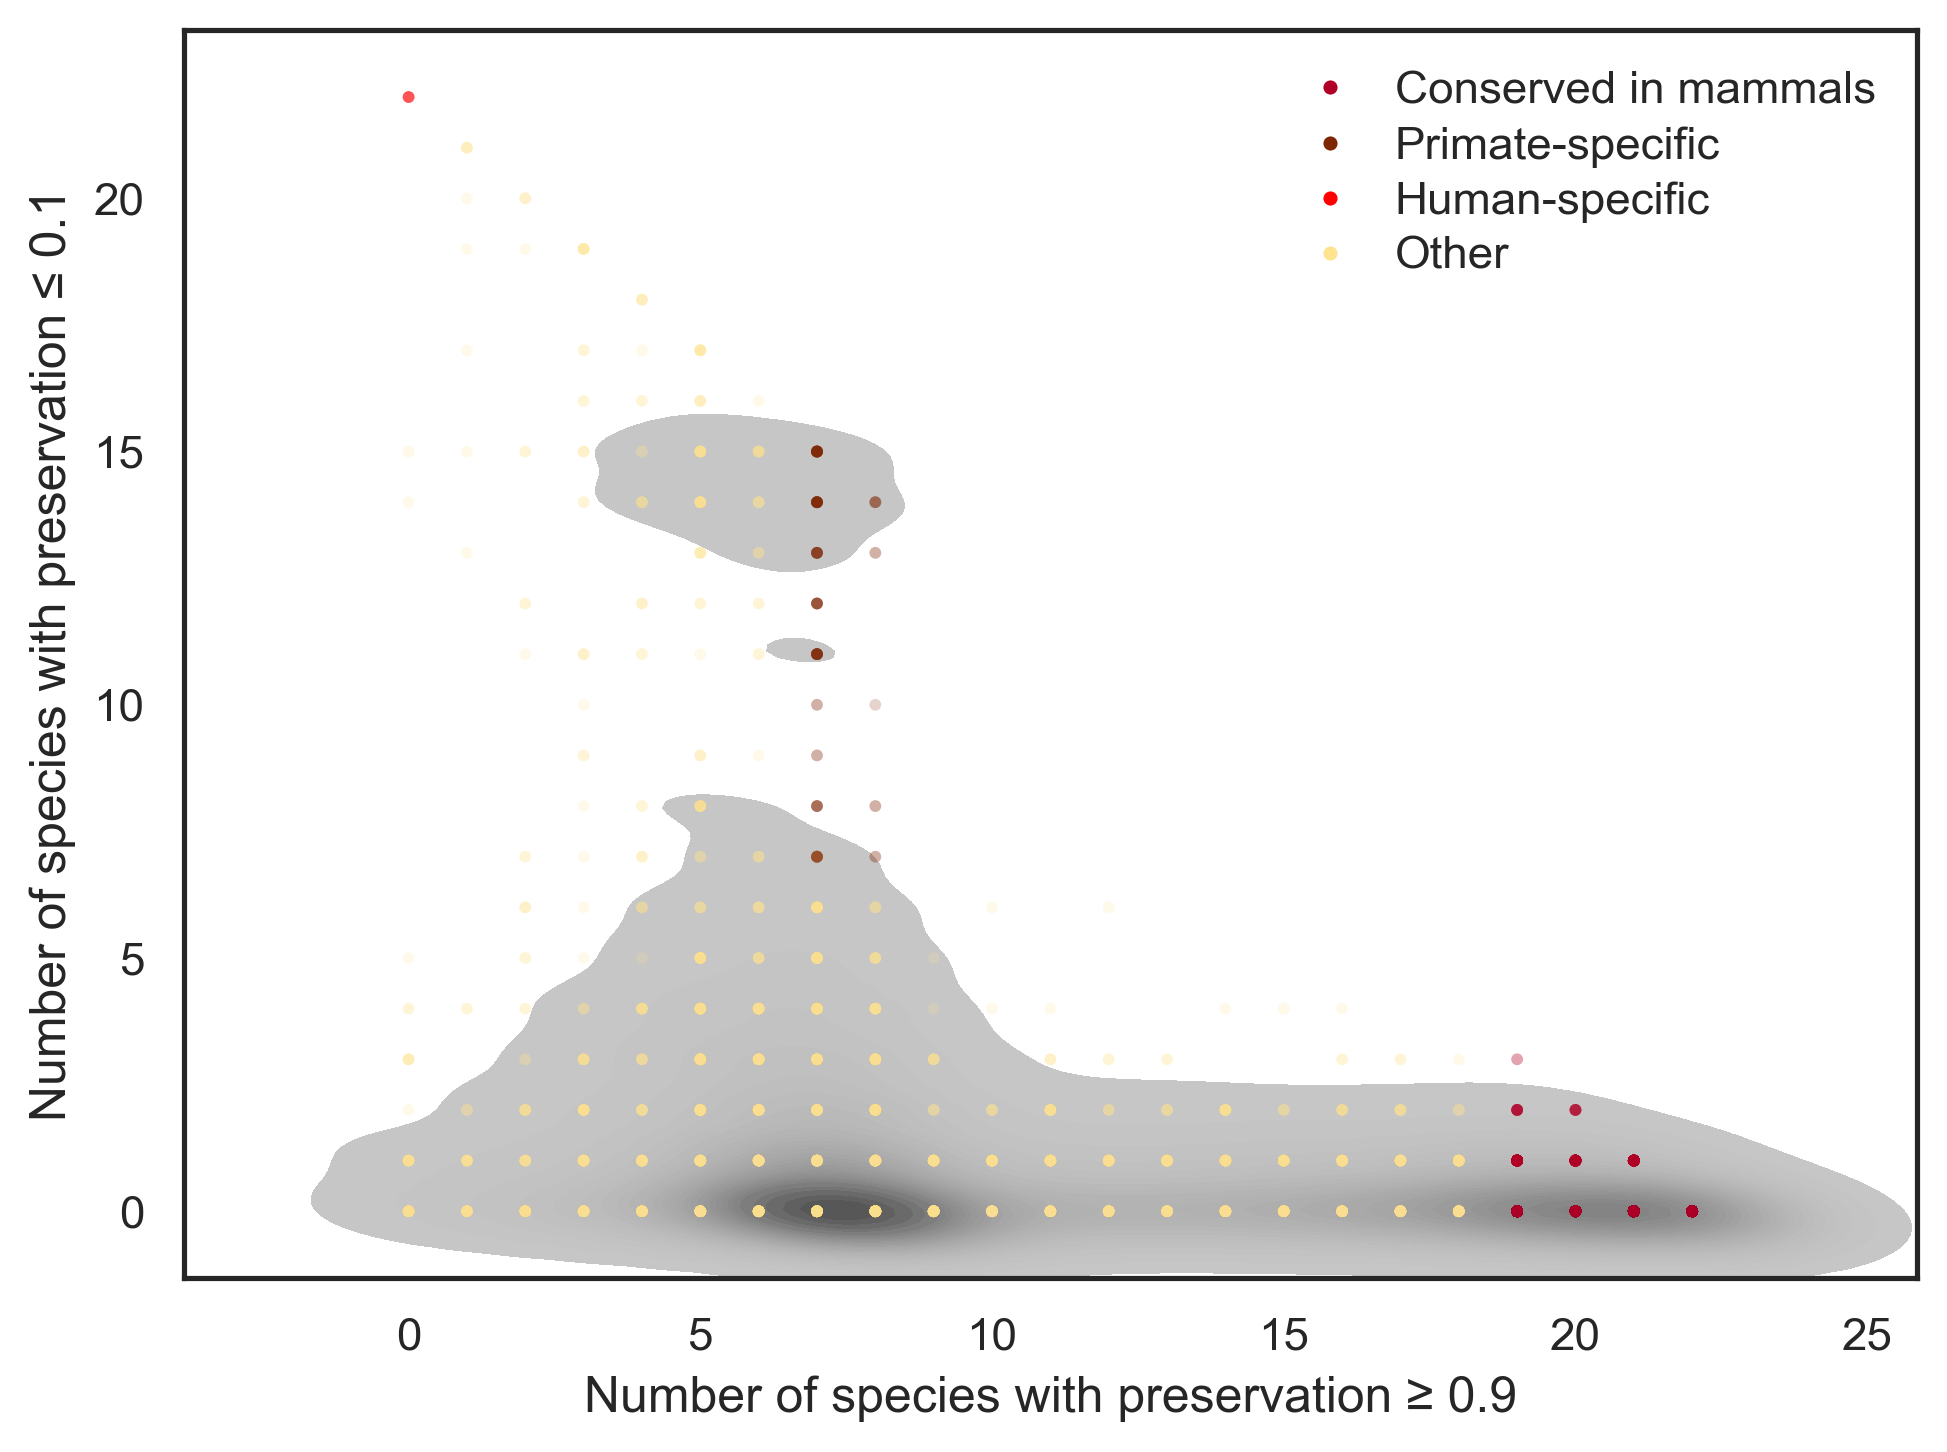

In [9]:
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(6.65, 5), dpi=300)

#color settings
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# density background
sns.kdeplot(
    data=df, x="N1", y="N2",
    color="#7A7A7A",
    fill=True, levels=30, thresh=0.02,
    ax=ax
)

# scatter with categories
sns.scatterplot(
    data=df, x="N1", y="N2",
    hue="category",
    palette=palette,
    s=8, alpha=0.20,
    linewidth=0,
    edgecolor="white", 
    ax=ax
)

# ax.set_title("Enhancer preservation to the human reference", fontsize=10 ,fontweight="bold")
ax.set_xlabel(f"Number of species with preservation ≥ {thr_hi}")
ax.set_ylabel(f"Number of species with preservation ≤ {thr_lo}")

# legend top-right
handles, labels = ax.get_legend_handles_labels()
pretty_labels = [mapping.get(l, l) for l in labels]
leg = ax.legend(
    handles, pretty_labels,
    loc="upper right",
    frameon=False,
    title=None,
    markerscale=1.2,
    handletextpad=0.4,
    labelspacing=0.3
)

for h in leg.legend_handles:
    try:
        h.set_alpha(1.0)
    except Exception:
        pass

plt.tight_layout()
plt.savefig(f"../plots/Scatter_enhancer_groups.pdf", dpi=300, bbox_inches="tight", transparent=True)
plt.show()
